In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Ensemble & Advanced Model
from sklearn.ensemble import (RandomForestClassifier,
                                AdaBoostClassifier,
                                GradientBoostingClassifier
                            )
from sklearn.neural_network import MLPClassifier

# Standard Classifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [3]:
import pickle
plt.style.use('ggplot')
#pd.set_option('max_columns', 200)

In [4]:
df = pd.read_csv("Iris.csv")

### Data Understanding

In [5]:
df.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [7]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [8]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [9]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


### Data Preparation

In [10]:
# example only
# df.drop(['Id'], axis=1)

In [11]:
df = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species']].copy()

In [12]:
df.shape

(150, 5)

In [13]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [14]:
df = df.rename(columns={'SepalLengthCm': 'sepallengthcm',
                   'SepalWidthCm': 'sepalwidthcm',
                   'PetalLengthCm': 'petallengthcm',
                   'PetalWidthCm': 'petalwidthcm',
                   'Species': 'species'})

In [15]:
df.head()

,sepallengthcm,sepalwidthcm,petallengthcm,petalwidthcm,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [16]:
df.isna().sum()

sepallengthcm    0
sepalwidthcm     0
petallengthcm    0
petalwidthcm     0
species          0
dtype: int64

In [17]:
df.columns

Index(['sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm',
       'species'],
      dtype='object')

In [18]:
df = df.loc[~df.duplicated(subset=['sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm',
       'species'])] \
       .reset_index(drop=True).copy()

In [19]:
df.shape

(147, 5)

### Feature Understanding

In [20]:
df['sepallengthcm'].value_counts()

5.0    10
5.1     9
6.3     9
6.7     8
5.7     8
5.5     7
6.4     7
5.8     6
5.4     6
6.1     6
6.0     6
5.6     6
4.8     5
6.5     5
4.9     4
6.2     4
7.7     4
6.9     4
4.6     4
5.2     4
5.9     3
4.4     3
7.2     3
6.8     3
6.6     2
4.7     2
7.6     1
7.4     1
7.3     1
7.0     1
7.1     1
5.3     1
4.3     1
4.5     1
7.9     1
Name: sepallengthcm, dtype: int64

Text(0, 0.5, 'count')

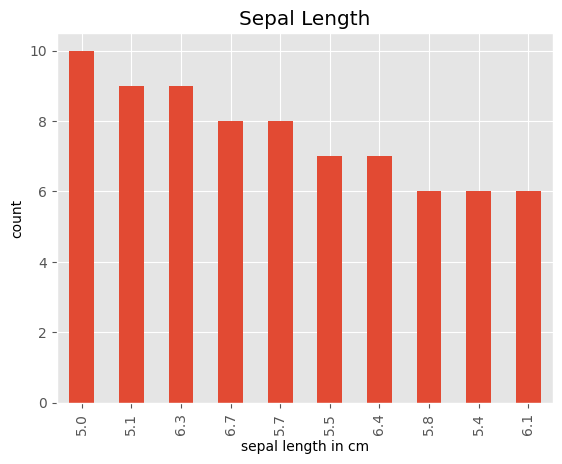

In [21]:
ax = df['sepallengthcm'].value_counts() \
    .head(10) \
    .plot(kind='bar', title='Sepal Length')
ax.set_xlabel('sepal length in cm')
ax.set_ylabel('count')

Text(0.5, 0, 'petal width')

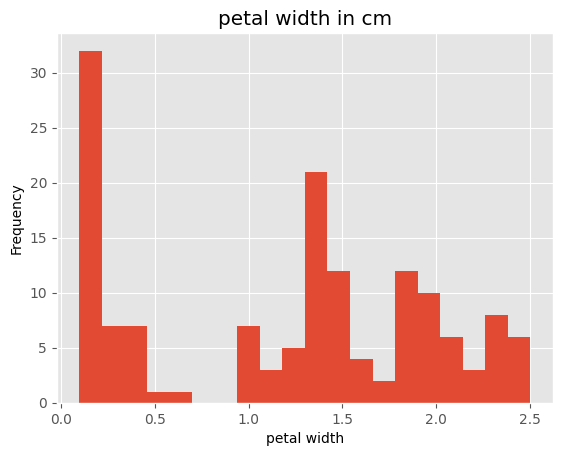

In [22]:
ax = df['petalwidthcm'].plot(kind='hist', 
                             bins=20, 
                             title='petal width in cm')
ax.set_xlabel('petal width')

Text(0.5, 0, 'petal width')

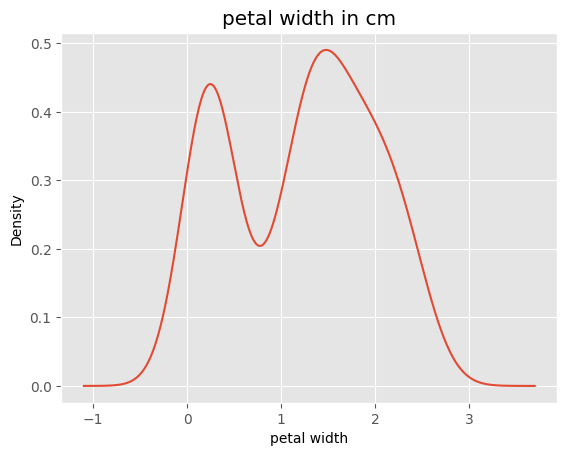

In [23]:
ax = df['petalwidthcm'].plot(kind='kde', 
                             title='petal width in cm')
ax.set_xlabel('petal width')

### Feature Relationships

<Axes: title={'center': 'sepal vs petal'}, xlabel='petalwidthcm', ylabel='sepallengthcm'>

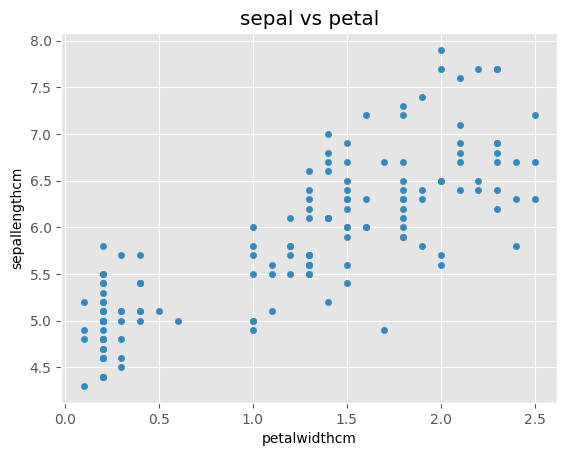

In [24]:
df.plot(kind='scatter', 
        x='petalwidthcm',
        y='sepallengthcm',
        title = 'sepal vs petal')

<Axes: xlabel='petalwidthcm', ylabel='sepallengthcm'>

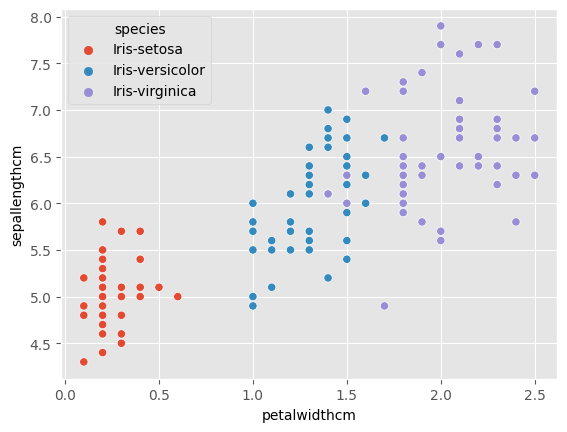

In [25]:
sns.scatterplot(x='petalwidthcm',
                y='sepallengthcm',
                hue = 'species',
                data=df)

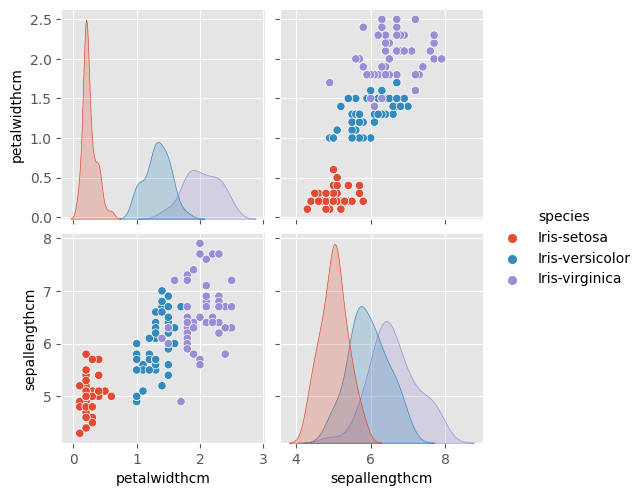

In [26]:
sns.pairplot(df, 
             vars=['petalwidthcm','sepallengthcm'],
             hue='species')
plt.show()

In [27]:
df_corr = df[['sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm',
            ]].dropna().corr()

<Axes: >

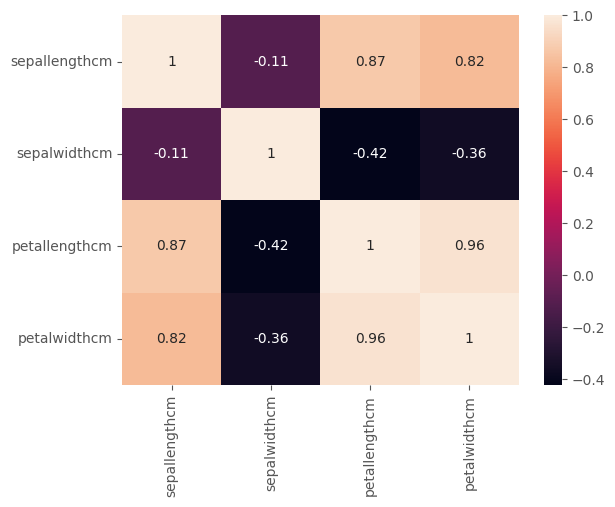

In [28]:
sns.heatmap(df_corr, annot=True)

### Ask question about the data

In [29]:
# not applicable for this dataset

### Creating a machine learning model

In [49]:
x = df.iloc[:,:-1] 
y = df.iloc[:, -1]

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [53]:
RFC = RandomForestClassifier()
ADA = AdaBoostClassifier()
GBC = GradientBoostingClassifier()
MLPC = MLPClassifier()
SV = SVC()
LR = LogisticRegression()
KNC = KNeighborsClassifier()
DTC = DecisionTreeClassifier()
GNB = GaussianNB()
LDA = LinearDiscriminantAnalysis()

In [54]:
for i in [RFC, ADA, GBC, MLPC, SV, LR, KNC, DTC, GNB, LDA]:
    i.fit(x_train, y_train)
    #predictions = i.predict(x_test)
    accuracy = i.score(x_test, y_test)
    print(f"{i}: {accuracy:.4f}")
    pickle.dump(i, open(f"{i}model.pkl", "wb"))

RandomForestClassifier(): 0.9333
AdaBoostClassifier(): 0.9333
GradientBoostingClassifier(): 0.9333
MLPClassifier(): 0.9333
SVC(): 0.9333
LogisticRegression(): 0.9333
KNeighborsClassifier(): 0.9333
DecisionTreeClassifier(): 0.9667
GaussianNB(): 0.9667
LinearDiscriminantAnalysis(): 0.9667


In [55]:
GBC.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [56]:
acc = GBC.score(x_test, y_test)
print(f"{acc:.4f}")

0.9333


In [57]:
prediction = RFC.predict([[5.1, 3.5, 1.4, 0.2]])
print(prediction[0])

Iris-setosa
